In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df =  pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [4]:
df.head(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,bptp terra,sector 37d,1.6,7302.0,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up area: 2000 sq.ft. (185.81 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),4,3,3+,others,7.0,North,1 to 5 Year Old,"['Airia Mall', 'Dwarka Expressway', 'Golf Course Extension Road', 'Euro International School', 'DPG Institute of Technology', 'Medanta -The Medicity', 'Amma Hospital', 'Indira Gandhi International Airport', 'DLF Corporate Greens', 'Holiday Inn Sector 90', 'SkyJumper Trampoline Park']","['1 Wardrobe', '5 Fan', '1 Exhaust Fan', '21 Light', '1 Modular Kitchen', '1 Chimney', '6 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"


## 1. areaWithType

In [5]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
3715,9.40,3600.0,Plot area 400(334.45 sq.m.)
3284,0.50,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 sq.ft. (67.35 sq.m.)Carpet area: 675 sq.ft. (62.71 sq.m.)
3346,1.05,1350.0,Carpet area: 1350 (125.42 sq.m.)
1277,6.00,2430.0,Plot area 270(225.75 sq.m.)
313,2.10,1260.0,Carpet area: 1260 (117.06 sq.m.)


In [6]:
# This function extracts the super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)',text)
    if match:
        return float(match.group(1))
    return None

In [7]:
# This function extracts the Built up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
# This function checks if the area is provided in sq.m and converts it to sq.ft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639      # conversion factor from sq.m to sq.ft
    return area_value
        

In [9]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built UP area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)


In [10]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1297,1.30,flat,2040.0,Built Up area: 2040 (189.52 sq.m.),NaN,2040.0,NaN
2207,0.37,flat,500.0,Super Built up area 500(46.45 sq.m.)Built Up area: 425 sq.ft. (39.48 sq.m.)Carpet area: 366.48 sq.ft. (34.05 sq.m.),500.0,425.0,366.48
1957,8.00,house,8287.0,Plot area 362(33.63 sq.m.)Built Up area: 8286 sq.ft. (769.79 sq.m.),NaN,8286.0,NaN
937,1.15,flat,1245.0,Super Built up area 1245(115.66 sq.m.),1245.0,NaN,NaN
366,6.15,flat,3355.0,Built Up area: 3355 (311.69 sq.m.)Carpet area: 2200 sq.ft. (204.39 sq.m.),NaN,3355.0,2200.00


In [11]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))].sample(5)[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1104,2.72,flat,2350.0,Super Built up area 2350(218.32 sq.m.)Built Up area: 2250 sq.ft. (209.03 sq.m.)Carpet area: 2001 sq.ft. (185.9 sq.m.),2350.0,2250.00,2001.00
3063,0.80,flat,900.0,Super Built up area 1380(128.21 sq.m.)Built Up area: 1310 sq.ft. (121.7 sq.m.)Carpet area: 900 sq.ft. (83.61 sq.m.),1380.0,1310.00,900.00
220,1.60,flat,2003.0,Super Built up area 2003(186.08 sq.m.)Built Up area: 1500.29 sq.ft. (139.38 sq.m.)Carpet area: 1140.98 sq.ft. (106 sq.m.),2003.0,1500.29,1140.98
1113,2.99,flat,2527.0,Super Built up area 2527(234.77 sq.m.)Built Up area: 2200 sq.ft. (204.39 sq.m.)Carpet area: 2100 sq.ft. (195.1 sq.m.),2527.0,2200.00,2100.00
2504,1.77,flat,2408.0,Super Built up area 2408(223.71 sq.m.)Built Up area: 1450 sq.ft. (134.71 sq.m.)Carpet area: 1300 sq.ft. (120.77 sq.m.),2408.0,1450.00,1300.00


In [12]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))].shape # only 534 rows has all three values

(535, 20)

In [13]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
7,11.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,NaN,NaN
15,11.00,house,2700.0,Plot area 360(301.01 sq.m.)Built Up area: 361 sq.yards (301.84 sq.m.)Carpet area: 300 sq.yards (250.84 sq.m.),NaN,361.0,300.0
20,17.30,house,4466.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
32,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
34,12.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [14]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape
# 684 rows has plot area

(684, 7)

In [15]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          983
features                635
super_built_up_area    1891
built_up_area          2618
carpet_area            1859
dtype: int64

In [16]:
# extracting rows which has missing values for all three built ups
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]



In [17]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
7,11.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,NaN,NaN
20,17.30,house,4466.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
32,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
34,12.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
52,0.51,house,360.0,Plot area 40(33.45 sq.m.),NaN,NaN,NaN


In [18]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [19]:
# function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None
    

In [20]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# update the original dataframe
# gurgaon_properties.update(filtered_rows)

In [21]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
7,11.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,316.00,NaN
20,17.30,house,4466.0,Plot area 502(419.74 sq.m.),NaN,502.00,NaN
32,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.00,NaN
34,12.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
52,0.51,house,360.0,Plot area 40(33.45 sq.m.),NaN,40.00,NaN
53,2.30,house,1352.0,Plot area 160(133.78 sq.m.),NaN,160.00,NaN
56,12.50,house,2430.0,Plot area 270(225.75 sq.m.),NaN,270.00,NaN
57,0.80,house,1200.0,Plot area 1200(111.48 sq.m.),NaN,1200.00,NaN
61,11.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
67,5.25,house,1935.0,Plot area 215(179.77 sq.m.),NaN,215.00,NaN


In [22]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']
            

In [23]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [24]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
7,11.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,2844.00,NaN
20,17.30,house,4466.0,Plot area 502(419.74 sq.m.),NaN,4518.00,NaN
32,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.00,NaN
34,12.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
52,0.51,house,360.0,Plot area 40(33.45 sq.m.),NaN,360.00,NaN
53,2.30,house,1352.0,Plot area 160(133.78 sq.m.),NaN,160.00,NaN
56,12.50,house,2430.0,Plot area 270(225.75 sq.m.),NaN,2430.00,NaN
57,0.80,house,1200.0,Plot area 1200(111.48 sq.m.),NaN,1200.00,NaN
61,11.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
67,5.25,house,1935.0,Plot area 215(179.77 sq.m.),NaN,1935.00,NaN


In [25]:
# update the original dataframe
df.update(all_nan_df)

In [26]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          983
features                635
super_built_up_area    1891
built_up_area          2071
carpet_area            1859
dtype: int64

In [27]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,bptp terra,sector 37d,1.60,7302.0,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up area: 2000 sq.ft. (185.81 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),4,3,3+,others,7.0,North,1 to 5 Year Old,"['Airia Mall', 'Dwarka Expressway', 'Golf Course Extension Road', 'Euro International School', 'DPG Institute of Technology', 'Medanta -The Medicity', 'Amma Hospital', 'Indira Gandhi International Airport', 'DLF Corporate Greens', 'Holiday Inn Sector 90', 'SkyJumper Trampoline Park']","['1 Wardrobe', '5 Fan', '1 Exhaust Fan', '21 Light', '1 Modular Kitchen', '1 Chimney', '6 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",2191.0,2000.0,1800.0
1,flat,dlf express greens,manesar,1.60,6808.0,2350.0,Carpet area: 2350 (218.32 sq.m.),4,6,3+,"study room,pooja room,servant room",4.0,North-East,1 to 5 Year Old,"['Pooja Clinic', 'Dr. Sahil Clinic', 'Prakash Hospital', 'Shri Rade Clinic', 'Yadav Dental & Eye Care', 'Dental Hospital', 'Petrol pump Maitri motors', 'Petrol Pump', ""McDonald's"", ""McDonald's"", 'Rao Dhaba']",NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,NaN,2350.0
2,flat,mapsko royale ville,sector 82,1.12,8000.0,1400.0,Super Built up area 1790(166.3 sq.m.)Built Up area: 1500 sq.ft. (139.35 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),3,4,2,"pooja room,servant room",6.0,North-West,1 to 5 Year Old,"['Sapphire 83 Mall', 'Golf Course Ext Rd', ""St. Xavier's High School"", 'DPG Institute of Technology', 'Miracles Apollo Cradle', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park', 'Vishalgarh Farms', 'F9 Go Karting Gurgaon']","['4 Fan', '1 Exhaust Fan', '7 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",1790.0,1500.0,1400.0
3,flat,dlf regal gardens,sector 90,1.25,7339.0,1703.0,Super Built up area 1703(158.21 sq.m.),3,3,3,servant room,28.0,North,5 to 10 Year Old,"['SS Omnia, Sector 86', 'Numberdar market, IMT Manesar', ""Sodhi's Supermarket, Sector 82"", 'RPS International School', 'RHM Public School', 'ICICI Bank ATM, Sector 86', 'Silver Streak Multi Speciality', 'Aarvy Healthcare Super Speciality', 'Miracles Apollo Cradle Hospital

## 2. additionalRoom

In [28]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1589
servant room                                      705
study room                                        250
others                                            226
pooja room                                        165
store room                                         99
study room,servant room                            99
pooja room,servant room                            83
pooja room,study room,servant room,store room      72
servant room,others                                59
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          55
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
pooja room,st

In [29]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the 'additionalRoom' column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)



In [30]:
df.sample(5)[['study room', 'servant room', 'store room', 'pooja room', 'others']]

,study room,servant room,store room,pooja room,others
429,0,0,0,0,1
3501,0,0,0,0,0
3718,0,0,0,0,0
305,0,0,0,0,0
1622,0,0,0,0,0


In [31]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,bptp terra,sector 37d,1.60,7302.0,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up area: 2000 sq.ft. (185.81 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),4,3,3+,others,7.0,North,1 to 5 Year Old,"['Airia Mall', 'Dwarka Expressway', 'Golf Course Extension Road', 'Euro International School', 'DPG Institute of Technology', 'Medanta -The Medicity', 'Amma Hospital', 'Indira Gandhi International Airport', 'DLF Corporate Greens', 'Holiday Inn Sector 90', 'SkyJumper Trampoline Park']","['1 Wardrobe', '5 Fan', '1 Exhaust Fan', '21 Light', '1 Modular Kitchen', '1 Chimney', '6 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",2191.0,2000.0,1800.0,0,0,0,0,1
1,flat,dlf express greens,manesar,1.60,6808.0,2350.0,Carpet area: 2350 (218.32 sq.m.),4,6,3+,"study room,pooja room,servant room",4.0,North-East,1 to 5 Year Old,"['Pooja Clinic', 'Dr. Sahil Clinic', 'Prakash Hospital', 'Shri Rade Clinic', 'Yadav Dental & Eye Care', 'Dental Hospital', 'Petrol pump Maitri motors', 'Petrol Pump', ""McDonald's"", ""McDonald's"", 'Rao Dhaba']",NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,NaN,2350.0,1,1,0,1,0
2,flat,mapsko royale ville,sector 82,1.12,8000.0,1400.0,Super Built up area 1790(166.3 sq.m.)Built Up area: 1500 sq.ft. (139.35 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),3,4,2,"pooja room,servant room",6.0,North-West,1 to 5 Year Old,"['Sapphire 83 Mall', 'Golf Course Ext Rd', ""St. Xavier's High School"", 'DPG Institute of Technology', 'Miracles Apollo Cradle', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park', 'Vishalgarh Farms', 'F9 Go Karting Gurgaon']","['4 Fan', '1 Exhaust Fan', '7 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",1790.0,1500.0,1400.0,0,1,0,1,0
3,flat,dlf regal gardens,sector 90,1.25,7339.0,1703.0,Super Built up area 1703(158.21 sq.m.),3,3,3,servant room,28.0,North,5 to 10 Year Old,"['SS Omnia, Sector 86', 'Numberdar market, IMT Manesar', ""Sodhi's Supermarket, Sector 82"", 'RPS International School', 'RHM Public School', 'ICICI Bank ATM, Sector 86', 'Silver Streak Multi

## 3. agePossession

In [32]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1678
5 to 10 Year Old       576
0 to 1 Year Old        530
undefined              332
10+ Year Old           311
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Jun 2024                 7
Aug 2023                 7
Dec 2025                 7
Nov 2023                 5
Sep 2023                 4
By 2025                  4
Aug 2024                 4
Oct 2023                 4
Jul 2024                 4
Nov 2024                 3
May 2024                 3
Jan 2025                 3
Feb 2024                 3
Sep 2025                 2
Apr 2026                 2
Jun 2027                 2
Jul 2025                 2
By 2027                  2
Aug 2025                 2
Mar 2025                 2
Oct 2025                 2
Jul 2027      

In [33]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value:
        return "Under Construction"
    try:
        # For entries like "May 2024"
        if int(value.split(" ")[-1]) <= 2024:
            return "Relatively New"
        elif int(value.split(" ")[-1]) == 2025:
            return "New Property"
        elif int(value.split(" ")[-1]) > 2025:
            return "Under Construction"
    except:
        return "Undefined"


In [34]:
df["agePossession"] = df["agePossession"].apply(categorize_age_possession)

In [35]:
df["agePossession"].value_counts()

agePossession
Relatively New        1827
New Property           652
Moderately Old         576
Undefined              333
Old Property           311
Under Construction     108
Name: count, dtype: int64

## 4.Furnish Details

In [36]:
df.sample(5)[['furnishDetails', 'features']]

,furnishDetails,features
1814,"['6 Fan', '6 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
2195,NaN,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Lift(s)', 'Swimming Pool', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2068,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN
3124,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '18 Light', '6 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
712,"['1 Stove', '5 AC', '1 Chimney', '1 Modular Kitchen', '4 Wardrobe', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center']"


In [37]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[','').replace(']','').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(rf"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include)) # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing] # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [38]:
furnishings_df.shape

(3807, 19)

In [39]:
df[['furnishDetails']]

,furnishDetails
0,"['1 Wardrobe', '5 Fan', '1 Exhaust Fan', '21 Light', '1 Modular Kitchen', '1 Chimney', '6 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']"
1,NaN
2,"['4 Fan', '1 Exhaust Fan', '7 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']"
3,NaN
4,NaN
5,"['2 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']"
6,"['2 Wardrobe', '4 Fan', '2 Geyser', '4 Light', '3 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']"
7,"['4 Wardrobe', '9 Fan', '1 Exhaust Fan', '5 Geyser', '1 Stove', '69 Light', '7 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']"
8,NaN
9,"['4 Fan', '8 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']"


In [40]:
id(df),id(furnishings_df)

(1878072449248, 1878074721968)

In [41]:
furnishings_df = furnishings_df.drop(columns=['furnishDetails'])

In [42]:
furnishings_df.sample(5)

,TV,Bed,Dining Table,Geyser,Sofa,AC,Light,Exhaust Fan,Microwave,Wardrobe,Fridge,Chimney,Washing Machine,Stove,Modular Kitchen,Fan,Water Purifier,Curtains
1806,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0
2670,0,0,0,3,0,0,9,1,0,3,0,0,0,0,1,6,0,0
815,0,0,0,1,0,0,5,0,0,2,0,1,0,0,1,4,0,0
3031,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1894,0,0,0,2,0,0,5,1,0,3,0,0,0,0,0,5,0,1


In [43]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [44]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [45]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

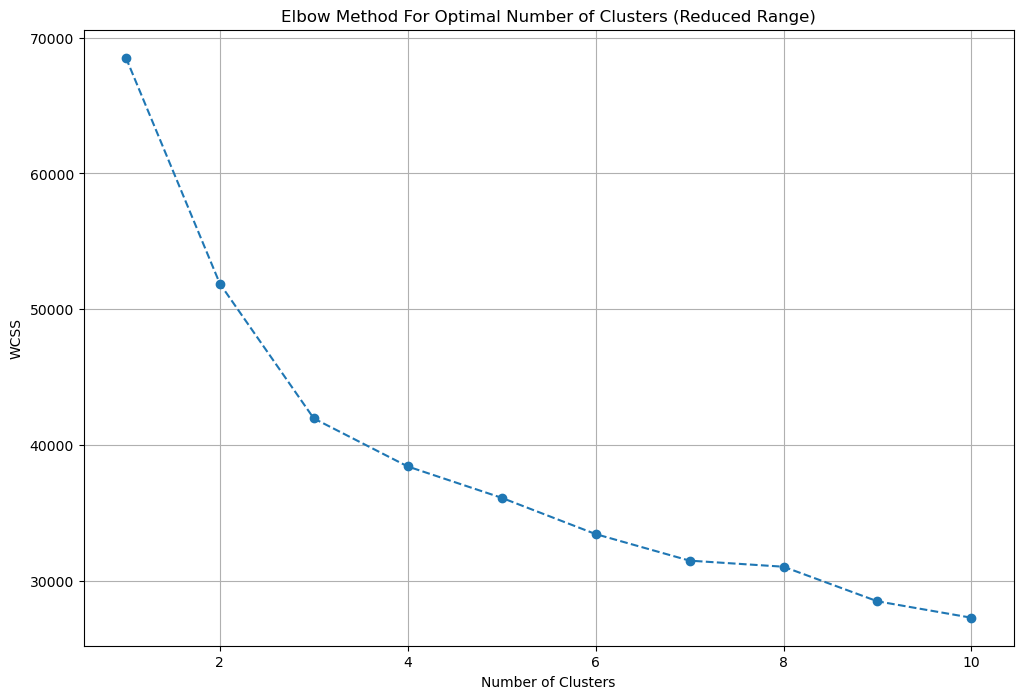

In [46]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [47]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [48]:
df = df.iloc[:, :-18]

In [49]:
furnishings_df['cluster'] = kmeans.labels_
centers = pd.DataFrame(kmeans.cluster_centers_, columns=furnishings_df.iloc[:, :-1].columns)
print(centers)

         TV       Bed  Dining Table    Geyser      Sofa        AC     Light  \
0 -0.046691 -0.060586     -0.083230  0.768831 -0.157219  0.552361  0.721767   
1 -0.109938 -0.098561     -0.171861 -0.445118 -0.162112 -0.340999 -0.372350   
2  1.498351  1.435555      2.392754  1.347462  2.644792  1.212731  0.739824   

   Exhaust Fan  Microwave  Wardrobe    Fridge   Chimney  Washing Machine  \
0     1.142752   0.022367  0.728575 -0.186131  0.774781        -0.160070   
1    -0.586571  -0.232984 -0.427242 -0.228982 -0.429041        -0.212461   
2     1.137204   2.577668  1.339559  3.558691  1.132673         3.239697   

      Stove  Modular Kitchen       Fan  Water Purifier  Curtains  
0  0.417743         1.027557  0.879161        0.284985  0.269944  
1 -0.343448        -0.529422 -0.470623       -0.313208 -0.206108  
2  1.904201         1.045408  1.098156        2.209372  1.047901  


In [50]:
# df['furnishing_type'] = cluster_assignments

In [51]:
cluster_map = {1:0, 0:1, 2:2}  # mapping
df['furnishing_type'] = furnishings_df['cluster'].map(cluster_map)


In [52]:

df.sample(5)[['furnishDetails','furnishing_type']]
# df[df['furnishing_type'] == 2][['furnishDetails','furnishing_type']]

# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished


,furnishDetails,furnishing_type
3108,NaN,0
2951,[],0
2324,NaN,0
951,"['1 Geyser', '7 Light', '6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
2609,"['2 Wardrobe', '2 Fan', '4 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0


## 5.features

In [53]:
df[['features']].sample(5)

,features
212,"['Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Separate entry for servant room', 'Piped-gas', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
1786,"['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']"
214,NaN
1837,NaN
3548,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Centrally Air Conditioned', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"


In [54]:
df['features'].isnull().sum()

635

#### Adding missing features from appartment data file

In [55]:
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [56]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [57]:
temp_df = df[df['features'].isnull()]

In [58]:
temp_df.shape

(635, 26)

In [59]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [60]:
df.loc[temp_df.index,'features'] = x.values

In [61]:
df['features'].isnull().sum()

481

In [62]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [63]:
# Convert the string represntation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultilabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [64]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
412,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
3098,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3582,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2735,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
86,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [65]:
features_binary_df.shape

(3807, 130)

In [66]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)
    

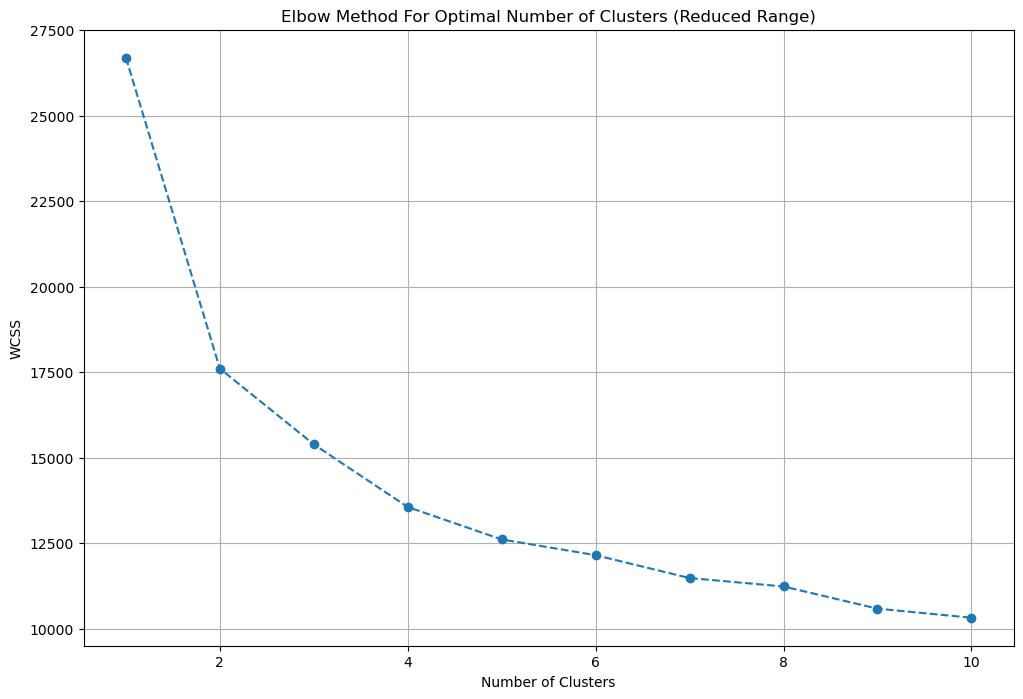

In [67]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [68]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [69]:
df['luxury_score'] = luxury_score

In [70]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,bptp terra,sector 37d,1.60,7302.0,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up area: 2000 sq.ft. (185.81 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),4,3,3+,others,7.0,North,Relatively New,"['Airia Mall', 'Dwarka Expressway', 'Golf Course Extension Road', 'Euro International School', 'DPG Institute of Technology', 'Medanta -The Medicity', 'Amma Hospital', 'Indira Gandhi International Airport', 'DLF Corporate Greens', 'Holiday Inn Sector 90', 'SkyJumper Trampoline Park']","['1 Wardrobe', '5 Fan', '1 Exhaust Fan', '21 Light', '1 Modular Kitchen', '1 Chimney', '6 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",2191.0,2000.0,1800.0,0,0,0,0,1,1,"[Security / Fire Alarm, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), Water purifier, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, Bank Attached Property, Visitor Parking, Swimming Pool, Park, Natural Light, Internet/wi-fi connectivity, Airy Rooms, Spacious Interiors, Low Density Society, Shopping Centre, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center, Water softening plant]",139
1,flat,dlf express greens,manesar,1.60,6808.0,2350.0,Carpet area: 2350 (218.32 sq.m.),4,6,3+,"study room,pooja room,servant room",4.0,North-East,Relatively New,"['Pooja Clinic', 'Dr. Sahil Clinic', 'Prakash Hospital', 'Shri Rade Clinic', 'Yadav Dental & Eye Care', 'Dental Hospital', 'Petrol pump Maitri motors', 'Petrol Pump', ""McDonald's"", ""McDonald's"", 'Rao Dhaba']",NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,NaN,2350.0,1,1,0,1,0,0,"[Feng Shui / Vaastu Compliant, Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",49
2,flat,mapsko royale ville,sector 82,1.12,8000.0,1400.0,Super Built up area 1790(166.3 sq.m.)Built Up area: 1500 sq.ft. (139.35 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),3,4,2,"pooja room,servant room",6.0,North-West,Relatively New,"['Sapphire 83 Mall', 'Golf Course Ext Rd', ""St. Xavier's High School"", 'DPG Institute of Technology', 'Miracles Apollo Cradle', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park', 'Vishalgarh Farms', 'F9 Go Karting Gurgaon']","['4 Fan', '1 Exhaust Fan', '7 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity'

In [71]:
# cols to drop -> nearbyLocations, furnishDetails, features, features_list, additionalRoom
df.drop(columns=['nearbyLocations', 'furnishDetails', 'features', 'features_list', 'additionalRoom'], inplace=True)


In [72]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3421,flat,eldeco accolade,sohna road,0.96,6571.0,1461.0,Super Built up area 1457(135.36 sq.m.)Carpet area: 849 sq.ft. (78.87 sq.m.),2,2,3+,14.0,East,Relatively New,1457.0,NaN,849.0,1,0,0,0,0,0,151
267,flat,bestech park view ananda,sector 81,1.15,6927.0,1660.0,Super Built up area 1660(154.22 sq.m.)Carpet area: 1282 sq.ft. (119.1 sq.m.),3,2,3+,6.0,South,Relatively New,1660.0,NaN,1282.0,1,0,0,0,0,1,104
641,flat,puri diplomatic greens,sector 111,2.65,11963.0,2215.0,Super Built up area 2215(205.78 sq.m.),3,4,3+,19.0,South-East,Relatively New,2215.0,NaN,NaN,1,1,1,1,0,0,65
2764,flat,umang winter hills,sector 77,1.35,7780.0,1735.0,Super Built up area 1735(161.19 sq.m.)Carpet area: 1199 sq.ft. (111.39 sq.m.),3,3,3+,7.0,NaN,New Property,1735.0,NaN,1199.0,0,0,1,0,0,1,96
3714,house,huda sector-56 gurgaon,sector 56,3.60,24845.0,1449.0,Plot area 161(134.62 sq.m.),5,5,3+,3.0,North-East,Moderately Old,NaN,1449.0,NaN,0,0,0,0,1,0,47


In [73]:
df.shape

(3807, 23)

In [74]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3807 entries, 0 to 3806
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3807 non-null   object 
 1   society              3806 non-null   object 
 2   sector               3807 non-null   object 
 3   price                3789 non-null   float64
 4   price_per_sqft       3789 non-null   float64
 5   area                 3789 non-null   float64
 6   areaWithType         3807 non-null   object 
 7   bedRoom              3807 non-null   int64  
 8   bathroom             3807 non-null   int64  
 9   balcony              3807 non-null   object 
 10  floorNum             3788 non-null   float64
 11  facing               2702 non-null   object 
 12  agePossession        3807 non-null   object 
 13  super_built_up_area  1916 non-null   float64
 14  built_up_area        1736 non-null   float64
 15  carpet_area          1948 non-null   f